### SARSA (with $\varepsilon$-greedy action selection)

In SARSA, the agent also follows an $\varepsilon$-greedy policy in order to explore the environment. Unlike Q-learning, however, the update target uses the *actual action that the agent will take next*.

The update rule is

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\Big[
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1})
-
Q(S_t,A_t)
\Big].
$$

Because the next action $A_{t+1}$ is sampled from the same $\varepsilon$-greedy policy used to generate the data, SARSA learns the value of the *actual behavior policy*. This is why SARSA is called an **on-policy** method.

In the Cliff Walking problem, SARSA learns that exploratory actions can occasionally lead the agent into the cliff. As a result, it tends to prefer a safer path farther away from the cliff edge. Although this path is longer, it often produces a higher average reward during learning because it reduces the risk of large negative rewards caused by exploration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import GridWorld as GW

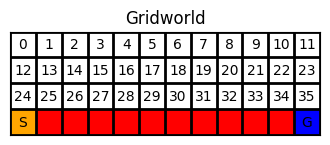

In [2]:
gw = GW.CliffWalking_Example()
gw.plot_gridworld()

In [3]:
def epsilon_greedy_policy(gridworld, Q, epsilon=0.1):

    policy = np.zeros_like(Q)
    states_, actions_ = np.nonzero((Q.T == np.max(Q, axis=1)).T)
    n_actions = len(gridworld.actions)
    for s in np.arange(gridworld.nstates):
        greedy_action = np.random.choice(actions_[states_ == s])
        for a in range(len(gridworld.actions)):
            if a != greedy_action:
                policy[s, a] = epsilon / n_actions
            else:
                policy[s, a] = 1.0 - epsilon + epsilon / n_actions

    return policy

def sarsa(gridworld, episodes=10, gamma=0.95, alpha=0.1):

    n_actions = len(gridworld.actions)
    Q = np.zeros((gridworld.nstates, n_actions))

    rewards = []
    for i in range(episodes):
        s = gridworld.initial_state
        policy = epsilon_greedy_policy(gridworld, Q)
        a_idx = np.random.choice(n_actions, p=policy[s])  # epsilon-greedy action selection

        reward_episode = 0
        while not s == gridworld.terminal_state:

            a = gridworld.actions[a_idx]
            s_prime, r = gridworld.interact(s, a)

            reward_episode += r

            policy = epsilon_greedy_policy(gridworld, Q)

            a_idx_prime = np.random.choice(
                n_actions,
                p=policy[s_prime]
            )

            Q[s, a_idx] += alpha * (
                r + gamma * Q[s_prime, a_idx_prime] - Q[s, a_idx]
            )

            s = s_prime
            a_idx = a_idx_prime
        
        rewards.append(reward_episode)
    return Q, epsilon_greedy_policy(gridworld, Q, epsilon=0.0), rewards

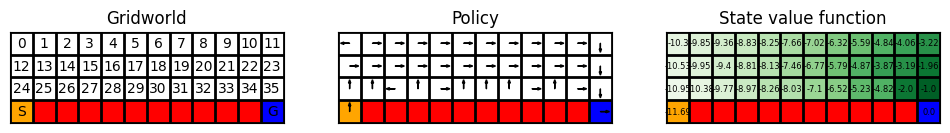

In [4]:
gw = GW.CliffWalking_Example()

Q, policy, rewards = sarsa(gw, episodes=1000)
V = np.sum(policy * Q, axis=1)

gw.plot_overview(V, policy)

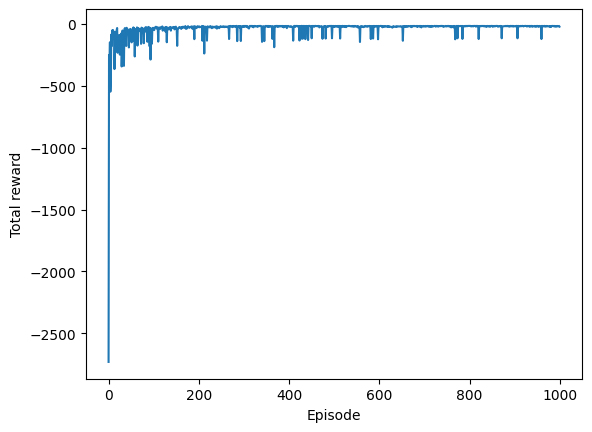

In [5]:
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.show()